# Telco Customer Churn Prediction using Logistic Regression

## Introduction

Customer churn is a critical business challenge in the telecommunications industry. Customer churn occurs when existing customers discontinue their services and switch to competitors. High churn rates can significantly impact a company's revenue, profitability, and long-term growth. Therefore, accurately identifying customers who are likely to leave is essential for developing effective customer retention strategies.

This project aims to build a Binary Classification Machine Learning model using **Logistic Regression** to predict whether a customer will churn based on demographic information, service subscriptions, account details, and billing characteristics. The project follows a complete Machine Learning workflow including Exploratory Data Analysis (EDA), data preprocessing, feature engineering, model training, evaluation, and interpretation.

The dataset used in this project is the **Telco Customer Churn Dataset**, a widely used industry dataset for classification tasks. It contains information about telecom customers, including their tenure, monthly charges, contract type, payment method, internet services, and churn status.

### Dataset Source

Dataset Name: Telco Customer Churn Dataset

Kaggle Link:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

### Project Objectives

* Understand customer characteristics and service usage patterns.
* Perform exploratory data analysis to identify trends and relationships.
* Preprocess data by handling missing values, encoding categorical variables, and scaling numerical features.
* Build a Logistic Regression model for churn prediction.
* Evaluate model performance using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC Curve, and ROC-AUC Score.
* Interpret model coefficients to understand factors influencing customer churn.
* Provide business insights and recommendations for reducing customer attrition.

This project demonstrates the practical application of Logistic Regression in solving real-world business problems and highlights the importance of data-driven decision-making in customer retention strategies.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Customer churn is one of the biggest challenges for telecom companies.

The objective of this project is to predict whether a customer will leave the company based on demographic, subscription, and billing information using Logistic Regression.

In [6]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

Numerical Columns
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

Categorical Columns
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')


C:\Users\ansha\AppData\Local\Temp\ipykernel_9908\2575668276.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


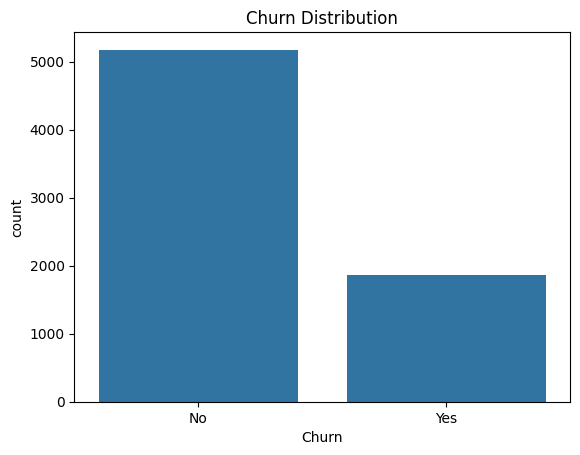

In [7]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

Most customers have not churned.
The dataset shows moderate class imbalance.

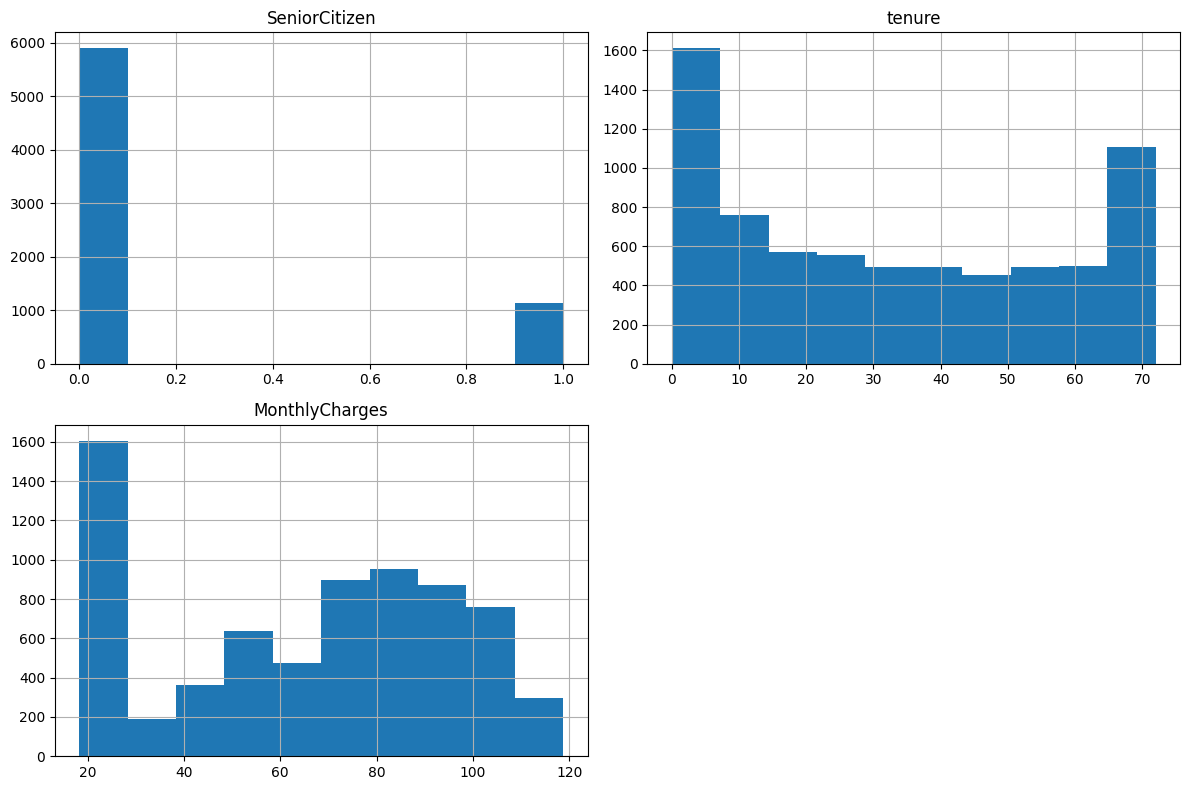

In [8]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [9]:
plt.savefig("histograms.png")

<Figure size 640x480 with 0 Axes>

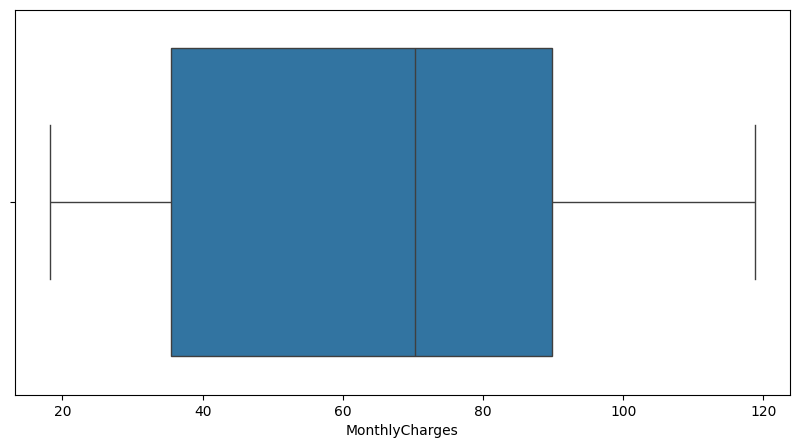

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["MonthlyCharges"])
plt.show()

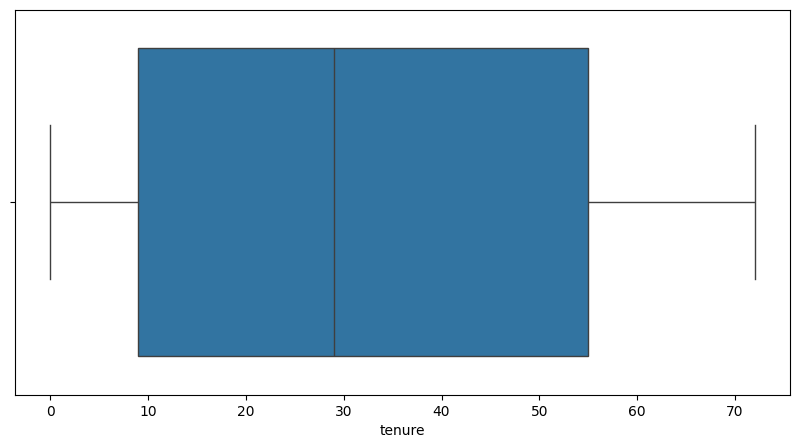

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["tenure"])
plt.show()

In [12]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

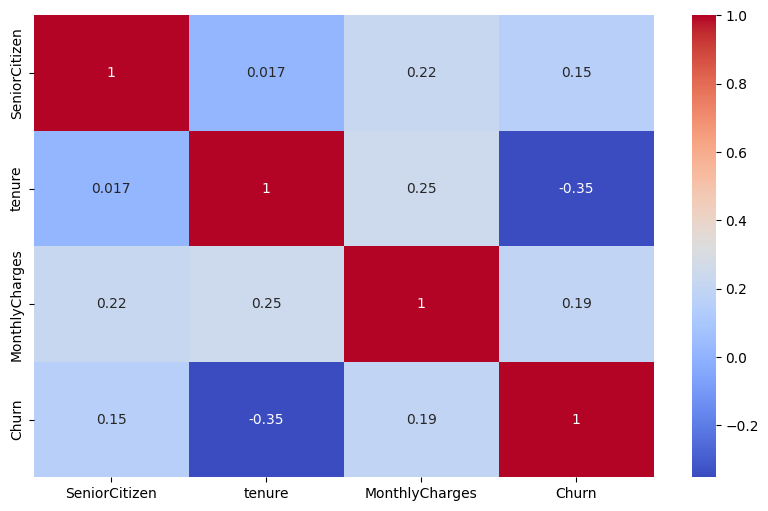

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [14]:
plt.savefig("heatmap.png")

<Figure size 640x480 with 0 Axes>

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [17]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

In [18]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [19]:
df.drop("customerID", axis=1, inplace=True)

In [20]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [21]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [24]:
model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train, y_train)

C:\Users\ansha\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.T

Penalty = L2
Prevents overfitting.

C = 1.0
Default regularization strength.

Solver = lbfgs
Efficient optimizer for binary classification.

Max_iter = 1000
Ensures convergence.

In [26]:
y_pred = model.predict(X_test)

In [27]:
accuracy_score(y_test, y_pred)

0.8069552874378992

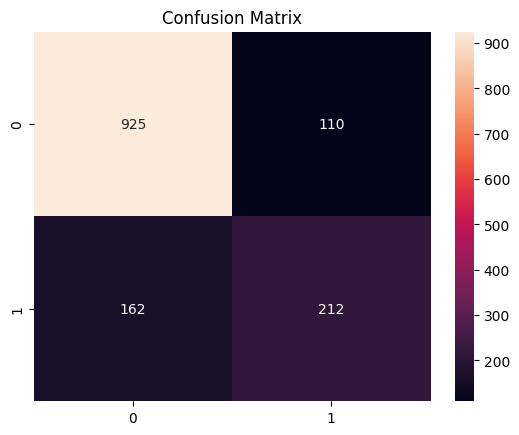

In [28]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

In [29]:
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [30]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



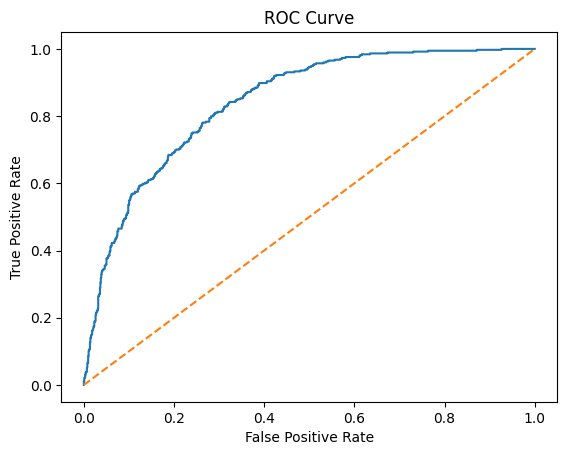

In [31]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.plot(fpr,tpr)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [32]:
roc_auc_score(
    y_test,
    y_prob
)

0.8415846443979436

In [33]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_[0]
})

importance.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.778760
3,TotalCharges,0.497246
23,StreamingMovies_Yes,0.258653
21,StreamingTV_Yes,0.258042
9,MultipleLines_Yes,0.216356
26,PaperlessBilling_Yes,0.181833
28,PaymentMethod_Electronic check,0.181456
17,DeviceProtection_Yes,0.053625
0,SeniorCitizen,0.052901
29,PaymentMethod_Mailed check,0.033133


The Logistic Regression model successfully predicted customer churn.

Key Findings:
- Contract type strongly influences churn.
- Customers with longer tenure are less likely to leave.
- Monthly charges impact churn probability.

Limitations:
- Linear decision boundary.
- Moderate class imbalance.

Future Improvements:
- SMOTE
- Random Forest
- XGBoost
- Additional feature engineering